<a href="https://colab.research.google.com/github/Alexandreliaudet/Midterm_AL/blob/main/FinalExam_EconModSim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:


import numpy as np

a = np.arange(0, 12)

a = 2 * a**2 - a + 3
a = a.reshape(6, 2)

print(a)

[[  3   4]
 [  9  18]
 [ 31  48]
 [ 69  94]
 [123 156]
 [193 234]]


Final probability of drawing a Three of a Kind: 2.35 %


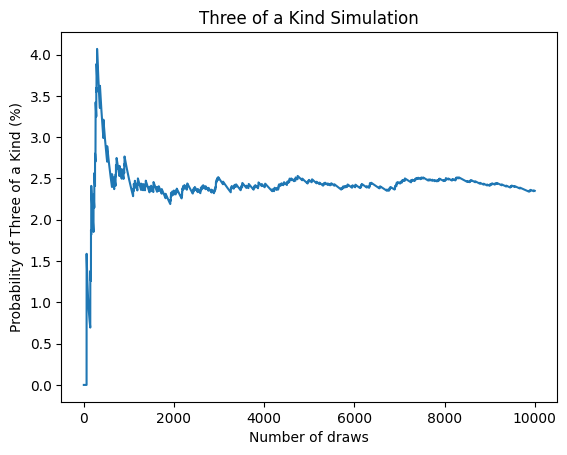

In [5]:
import random
import matplotlib.pyplot as plt

iterations = 10000  #@param {type:"slider", min:1000, max:50000, step:100}

class PlayingCard:
    SUITS = ["S", "H", "D", "C"]
    RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def __str__(self):
        return self.rank + self.suit


class Deck:
    def __init__(self):
        self.cards = []
        for suit in PlayingCard.SUITS:
            for rank in PlayingCard.RANKS:
                card = PlayingCard(suit, rank)
                self.cards.append(card)

    def shuffle(self):
        random.shuffle(self.cards)

    def deal(self):
        return self.cards.pop(0)


class PokerHand:
    def __init__(self):
        deck = Deck()
        deck.shuffle()
        self.cards = []
        for i in range(5):
            self.cards.append(deck.deal())

    def is_three_of_a_kind(self):
        ranks = []
        for card in self.cards:
            ranks.append(card.rank)

        counts = []
        for rank in ranks:
            count = 0
            for other_rank in ranks:
                if rank == other_rank:
                    count = count + 1
            counts.append(count)

        three_found = False
        pair_found = False
        four_found = False

        for count in counts:
            if count == 3:
                three_found = True
            elif count == 2:
                pair_found = True
            elif count == 4:
                four_found = True

        if three_found and pair_found == False and four_found == False:
            return True
        else:
            return False


hits = 0
x_values = []
y_values = []

for draw in range(1, iterations + 1):
    hand = PokerHand()

    if hand.is_three_of_a_kind():
        hits = hits + 1

    probability = (hits / draw) * 100

    x_values.append(draw)
    y_values.append(probability)

print("Final probability of drawing a Three of a Kind:", probability, "%")

plt.plot(x_values, y_values)
plt.xlabel("Number of draws")
plt.ylabel("Probability of Three of a Kind (%)")
plt.title("Three of a Kind Simulation")
plt.show()

/tmp/ipykernel_15030/963883565.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2009-01-01", end="2010-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


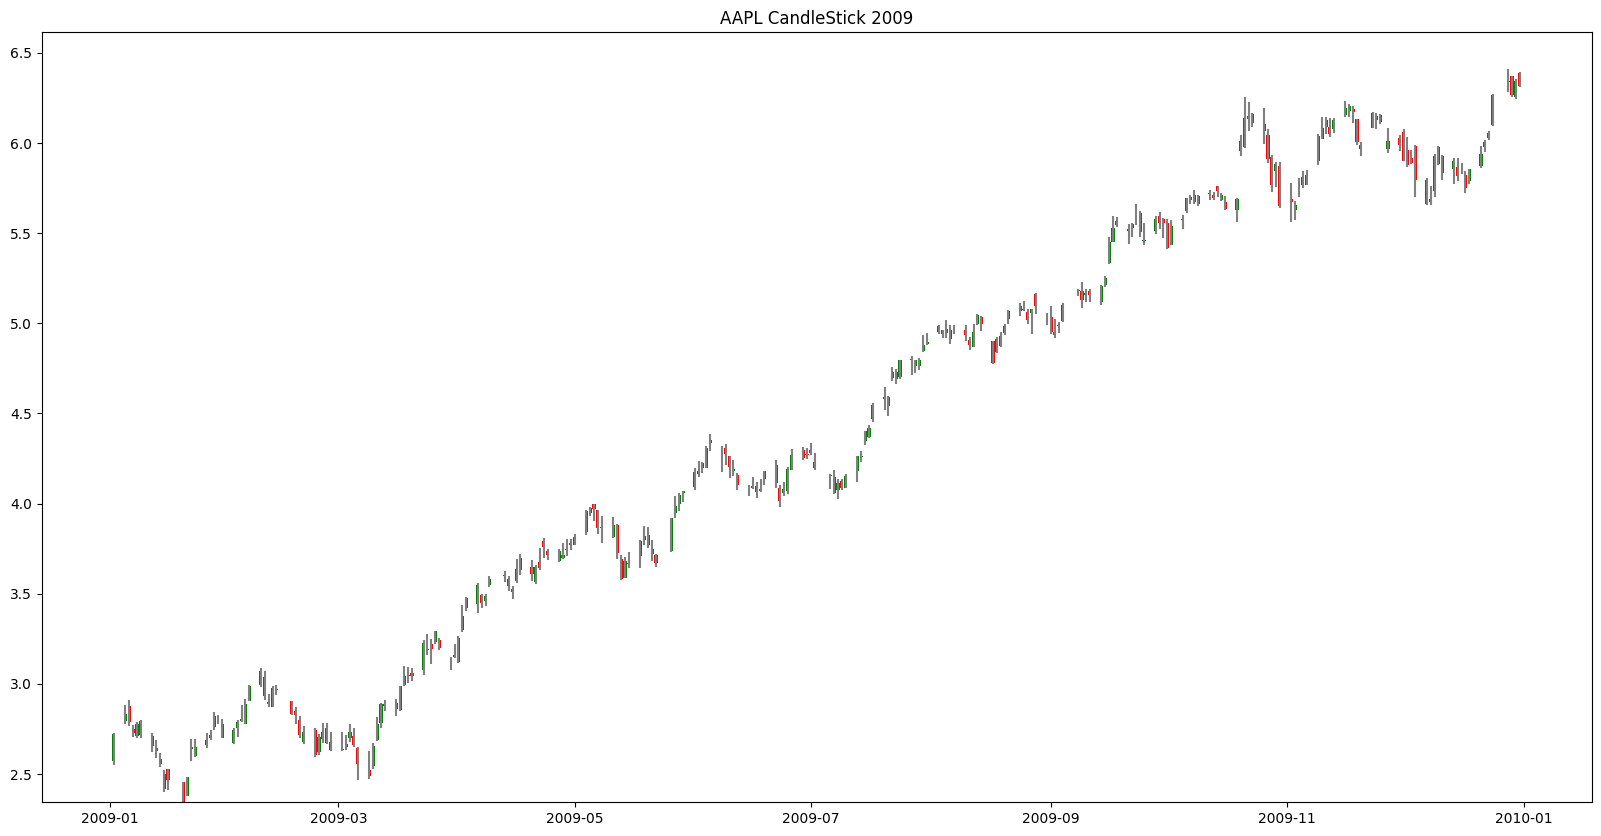

Best day for Apple in 2009:
2009-01-02 00:00:00
5.670685209642321
Worst day for Apple in 2009:
2009-02-23 00:00:00
-5.1282062488095335


In [7]:
!pip install yfinance

from matplotlib import pylab as plt
import pandas as pd
import yfinance as yf

company = "AAPL"
df = yf.download(company, start="2009-01-01", end="2010-01-01", multi_level_index=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

plt.style.use("default")

plt.figure(figsize=(20, 10))
plt.title(company + " CandleStick 2009")
plt.vlines(x=df.index, ymin=df["Low"], ymax=df["High"], color="gray")

green = df.loc[df["Open"] <= df["Close"], ["Open", "Close", "High", "Low"]].copy()
green["Height"] = green["Close"] - green["Open"]

red = df.loc[df["Open"] > df["Close"], ["Open", "Close", "High", "Low"]].copy()
red["Height"] = red["Open"] - red["Close"]

plt.bar(x=green.index, height=green["Height"], bottom=green["Open"], color="green")
plt.bar(x=red.index, height=red["Height"], bottom=red["Close"], color="red")

plt.show()

df["Percent Change"] = ((df["Close"] - df["Open"]) / df["Open"]) * 100

best_day = df["Percent Change"].idxmax()
worst_day = df["Percent Change"].idxmin()

print("Best day for Apple in 2009:")
print(best_day)
print(df.loc[best_day, "Percent Change"])

print("Worst day for Apple in 2009:")
print(worst_day)
print(df.loc[worst_day, "Percent Change"])

In [10]:
import numpy as np
import pandas as pd

df = pd.DataFrame(np.random.randn(4, 4), index=[1, 2, 3, 4], columns=['a', 'b', 'c', 'd'])
print(df)

print(df["b"][3])
print(df.loc[3, "b"])
print(df.iloc[2, 1])


          a         b         c         d
1  0.214378  1.789625 -0.836790  0.303762
2 -1.780333 -0.613207  1.829048  0.084072
3 -1.469836 -3.048480 -0.959755 -0.042022
4  0.012227  1.285745  0.998155 -0.252524
-3.0484801835382447
-3.0484801835382447
-3.0484801835382447


Final probability of drawing a Three of a Kind: 2.21 %


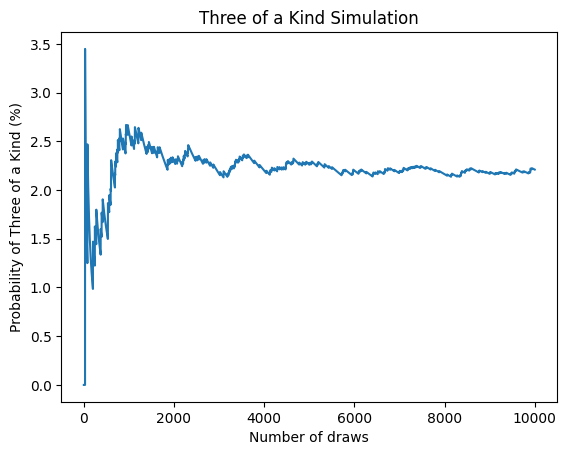

In [13]:
import random
import matplotlib.pyplot as plt

iterations = 10000  #@param {type:"slider", min:1000, max:50000, step:100}

class PlayingCard:
    SUITS = ["S", "H", "D", "C"]
    RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def __str__(self):
        return self.rank + self.suit


class Deck:
    def __init__(self):
        self.cards = []
        for suit in PlayingCard.SUITS:
            for rank in PlayingCard.RANKS:
                card = PlayingCard(suit, rank)
                self.cards.append(card)

    def shuffle(self):
        random.shuffle(self.cards)

    def deal(self):
        return self.cards.pop(0)


class PokerHand:
    def __init__(self):
        deck = Deck()
        deck.shuffle()
        self.cards = []
        for i in range(5):
            self.cards.append(deck.deal())

    def is_three_of_a_kind(self):
        ranks = []
        for card in self.cards:
            ranks.append(card.rank)

        counts = []
        for rank in ranks:
            count = 0
            for other_rank in ranks:
                if rank == other_rank:
                    count = count + 1
            counts.append(count)

        three_found = False
        pair_found = False
        four_found = False

        for count in counts:
            if count == 3:
                three_found = True
            elif count == 2:
                pair_found = True
            elif count == 4:
                four_found = True

        if three_found and pair_found == False and four_found == False:
            return True
        else:
            return False


hits = 0
x_values = []
y_values = []

for draw in range(1, iterations + 1):
    hand = PokerHand()

    if hand.is_three_of_a_kind():
        hits = hits + 1

    probability = (hits / draw) * 100

    x_values.append(draw)
    y_values.append(probability)

final_probability = (hits / iterations) * 100

print("Final probability of drawing a Three of a Kind:", final_probability, "%")

plt.plot(x_values, y_values)
plt.xlabel("Number of draws")
plt.ylabel("Probability of Three of a Kind (%)")
plt.title("Three of a Kind Simulation")
plt.show()